# HEALTH INFORMATICS - **CHI2012** PROJECT

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib


In [ ]:
# Load your dataset
from google.colab import files
uploaded = files.upload()

# Read CSV
data = pd.read_csv('data_stress.csv')

# Preview the data
data.head()


Saving data_stress.csv to data_stress.csv


,snoring range,respiration rate,body temperature,limb movement,blood oxygen,eye movement,hours of sleep,heart rate,Stress Levels
0,93.80,25.680,91.840,16.600,89.840,99.60,1.840,74.20,3
1,91.64,25.104,91.552,15.880,89.552,98.88,1.552,72.76,3
2,60.00,20.000,96.000,10.000,95.000,85.00,7.000,60.00,1
3,85.76,23.536,90.768,13.920,88.768,96.92,0.768,68.84,3
4,48.12,17.248,97.872,6.496,96.248,72.48,8.248,53.12,0


In [ ]:
# Separate features and target
X = data.drop('Stress Levels', axis=1)
y = data['Stress Levels']

print("Features:\n", X.head())
print("\nTarget:\n", y.head())


Features:
    snoring range  respiration rate  body temperature  limb movement  \
0          93.80            25.680            91.840         16.600   
1          91.64            25.104            91.552         15.880   
2          60.00            20.000            96.000         10.000   
3          85.76            23.536            90.768         13.920   
4          48.12            17.248            97.872          6.496   

   blood oxygen   eye movement  hours of sleep  heart rate   
0         89.840         99.60           1.840        74.20  
1         89.552         98.88           1.552        72.76  
2         95.000         85.00           7.000        60.00  
3         88.768         96.92           0.768        68.84  
4         96.248         72.48           8.248        53.12  

Target:
 0    3
1    3
2    1
3    3
4    0
Name: Stress Levels, dtype: int64


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


NameError: name 'train_test_split' is not defined

In [ ]:
# Initialize XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
}

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 243 candidates, totalling 729 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:25:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=3, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 1],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.7, 0.8, 1]},
             scoring='accuracy', verbose=1)

In [ ]:
print("Best Parameters Found:\n", grid_search.best_params_)


Best Parameters Found:
 {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}


In [ ]:
# Use the best model
best_model = grid_search.best_estimator_

# Predict on test data
y_pred = best_model.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9761904761904762

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       0.96      0.96      0.96        25
           2       0.96      0.96      0.96        25
           3       0.96      1.00      0.98        26
           4       1.00      1.00      1.00        25

    accuracy                           0.98       126
   macro avg       0.98      0.98      0.98       126
weighted avg       0.98      0.98      0.98       126


Confusion Matrix:
 [[24  1  0  0  0]
 [ 0 24  1  0  0]
 [ 0  0 24  1  0]
 [ 0  0  0 26  0]
 [ 0  0  0  0 25]]


In [ ]:
print(y.value_counts())


Stress Levels
3    126
1    126
0    126
2    126
4    126
Name: count, dtype: int64


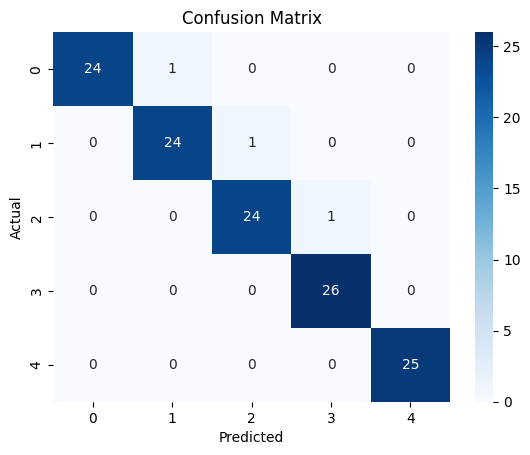

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
print("Cross-validation Accuracy: {:.2f}%".format(grid_search.best_score_ * 100))


Cross-validation Accuracy: 99.21%


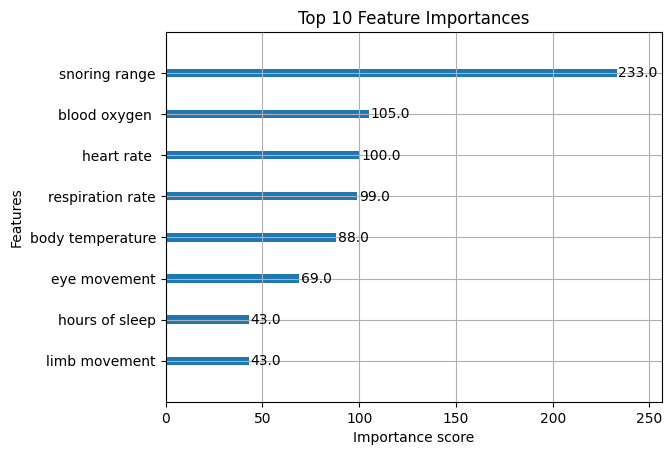

In [ ]:
xgb.plot_importance(best_model, max_num_features=10)
plt.title('Top 10 Feature Importances')
plt.show()


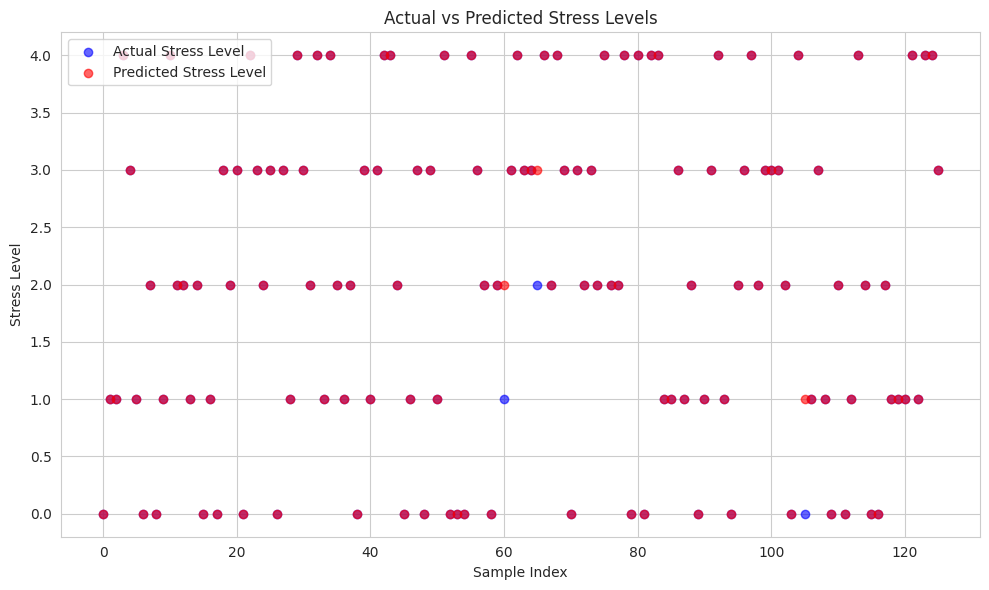

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



# Set the plot style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create a scatter plot
plt.scatter(range(len(y_test)), y_test, color='blue', alpha=0.6, label='Actual Stress Level')
plt.scatter(range(len(y_pred)), y_pred, color='red', alpha=0.6, label='Predicted Stress Level')

# Adding labels and title
plt.title('Actual vs Predicted Stress Levels')
plt.xlabel('Sample Index')
plt.ylabel('Stress Level')
plt.legend()
plt.tight_layout()

# Show plot
plt.show()


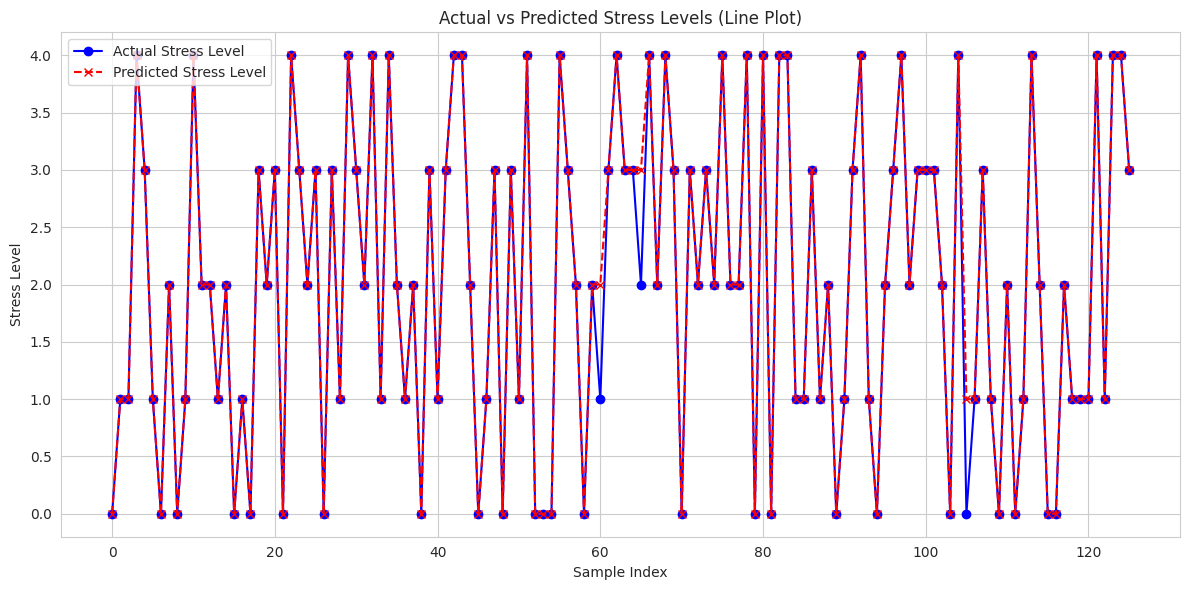

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Stress Level', color='blue', marker='o')
plt.plot(y_pred, label='Predicted Stress Level', color='red', linestyle='--', marker='x')

plt.title('Actual vs Predicted Stress Levels (Line Plot)')
plt.xlabel('Sample Index')
plt.ylabel('Stress Level')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Save model for future use (web integration)
joblib.dump(best_model, 'stress_detection_xgb_model.pkl')
print("Model saved as 'stress_detection_xgb_model.pkl' ✅")

# Optional: Download the model file to your local system
files.download('stress_detection_xgb_model.pkl')


Model saved as 'stress_detection_xgb_model.pkl' ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>